# Task 5: Personal Loan Acceptance Prediction

### Objective
The objective of this notebook is to predict which bank customers are likely to accept a personal loan/term deposit marketing offer. By using historical data from the Bank Marketing Dataset (`bank-full.csv`), we build classification models to target high-potential customer segments, thereby maximizing conversion rates and minimizing operational costs.

### Dataset Description
The dataset contains 45,211 rows representing customer interactions. 
* **Demographics:** Age, Job, Marital Status, Education
* **Financials:** Default history, Average Yearly Balance, Housing Loan, Personal Loan
* **Campaign Details:** Contact Type, Day, Month, Last Call Duration, Previous Contacts
* **Target (`y`):** Has the client subscribed to the product? (binary: 'yes','no')

# Dependencies and Data Loading

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.shape

(45211, 17)

In [28]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [6]:
# Target Distribution

df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

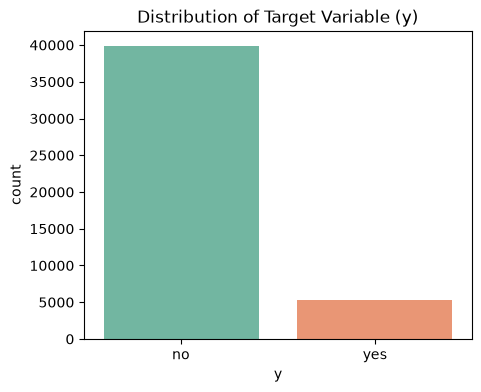

In [7]:
# ==========================================================
# 1. Inspect target distribution to check for imbalance
# ==========================================================
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='y', hue='y', palette='Set2', legend=False)
plt.title('Distribution of Target Variable (y)')
plt.show()

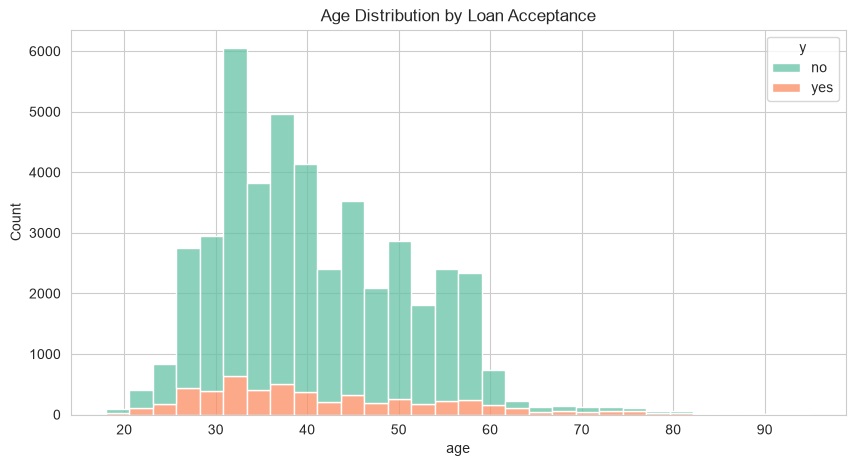

In [87]:
# ==========================================================
# 2. Analyze customer age profiles against acceptance
# ==========================================================
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='y', multiple='stack', bins=30, palette='Set2')
plt.title('Age Distribution by Loan Acceptance')
plt.show()

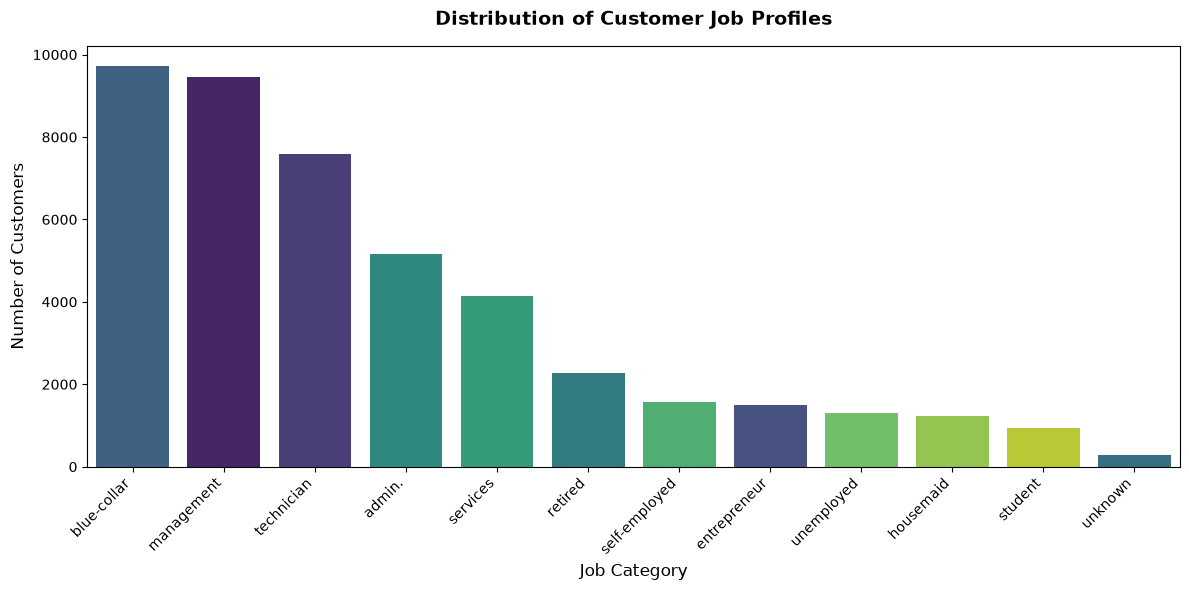

In [ ]:
# ==========================================================
# 3. Job Distribution Plot (Optimized & Sorted)
# ==========================================================
plt.figure(figsize=(12, 6))

# Using Seaborn countplot and ordering from most to least frequent job
sns.countplot(
    data=df, 
    x='job', 
    order=df['job'].value_counts().index, 
    palette='viridis',
    hue='job',
    legend=False
)

# Formatting text fields
plt.title("Distribution of Customer Job Profiles", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Job Category", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates and cleanly aligns labels

plt.tight_layout()  # Fixes overlapping boundaries
plt.show()

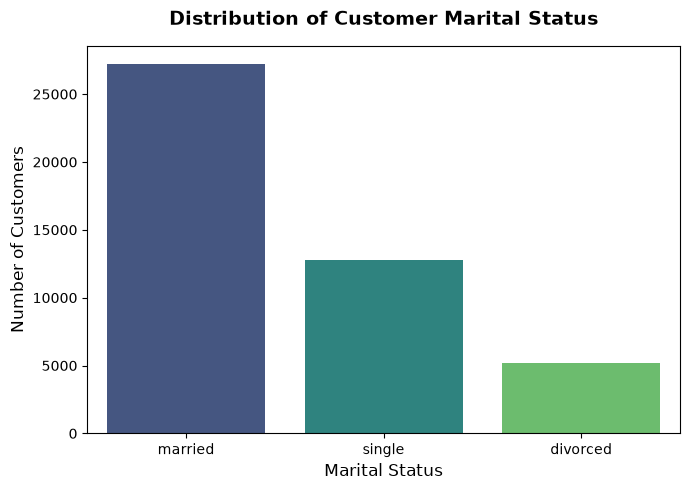

In [ ]:
# ==========================================================
# 4. Marital Status Distribution Plot
# ==========================================================
plt.figure(figsize=(7, 5))

# Visualizing marital distribution matching the aesthetic of the first chart
sns.countplot(
    data=df, 
    x='marital', 
    order=df['marital'].value_counts().index,
    palette='viridis',
    hue='marital',
    legend=False
)

plt.title("Distribution of Customer Marital Status", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Marital Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

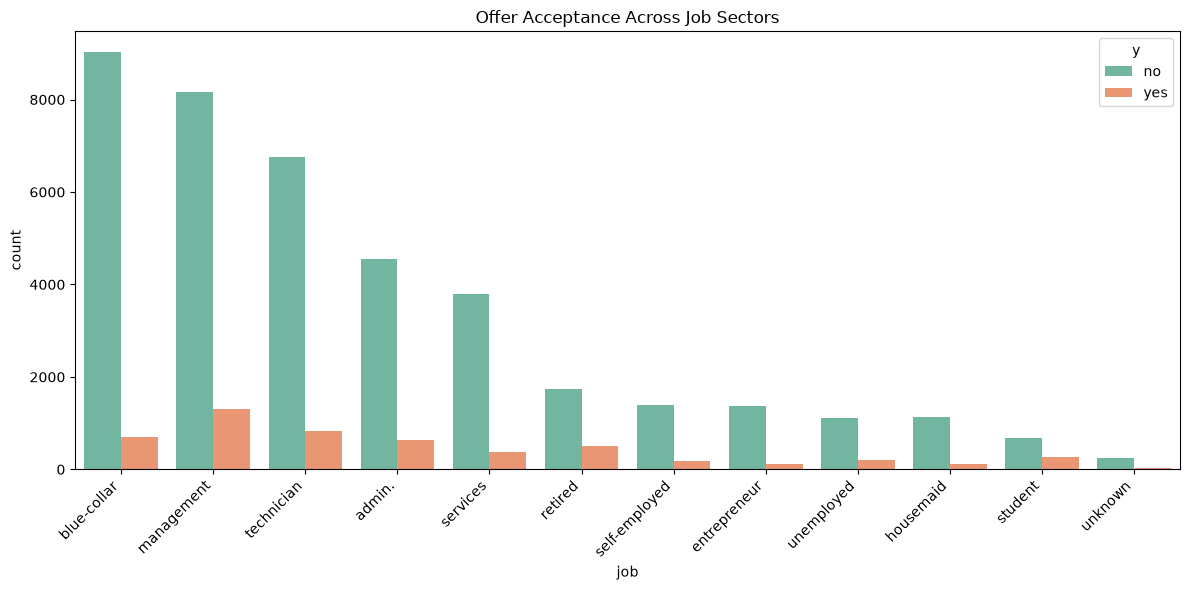

In [ ]:
# ==========================================================
# 5. Analyze job profiles against acceptance
# ==========================================================
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue='y', palette='Set2', order=df['job'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Offer Acceptance Across Job Sectors')
plt.tight_layout()
plt.show()

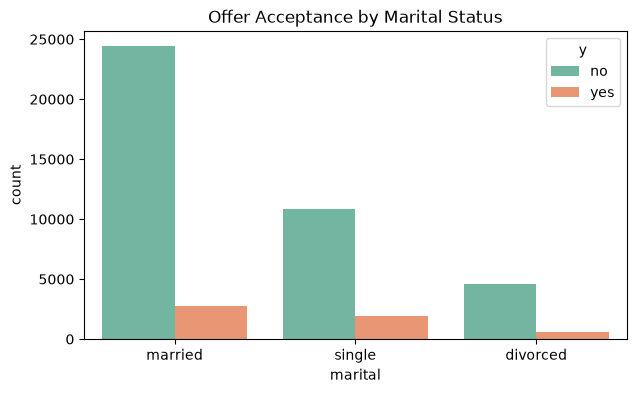

In [ ]:
# ==========================================================
# 6. Analyze impact of marital status
# ==========================================================
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='marital', hue='y', palette='Set2')
plt.title('Offer Acceptance by Marital Status')
plt.show()

# Data Preparation & Feature Engineering

In [12]:
# Encode Categorical Variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

In [13]:
# Exclude target 'y' from encoding right now to keep it separate or binary map it
df_encoded = df.copy()
for col in categorical_cols:
    if col != 'y':
        df_encoded[col] = le.fit_transform(df_encoded[col])

In [14]:
# Map target 'y' to binary 0 and 1
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

In [15]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

In [16]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# Scale continuous features for Logistic Regression performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")

Training set size: 36168 | Testing set size: 9043


# Model Training & Evaluation

We will train both a Logistic Regression model and a Decision Tree classifier to compare performance.

In [18]:
# ==========================================
# MODEL 1: LOGISTIC REGRESSION
# ==========================================
print("\n--- Training Decision Tree ---")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)


--- Training Decision Tree ---


In [20]:
# Evaluate predictions
print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_preds))
print("\nClassification Report:\n", classification_report(y_test, lr_preds))

=== Logistic Regression Performance ===
Accuracy: 0.8914077186774301

Confusion Matrix:
 [[7822  163]
 [ 819  239]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.59      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



In [21]:
# ==========================================
# MODEL 2: DECISION TREE CLASSIFIER
# ==========================================
print("\n--- Training Decision Tree ---")
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42) # Depth limited to prevent overfitting
dt_model.fit(X_train, y_train) # Trees don't strictly require scaling
dt_preds = dt_model.predict(X_test)


--- Training Decision Tree ---


In [22]:
# Evaluate predictions
print("\n=== Decision Tree Performance ===")
print("Accuracy:", accuracy_score(y_test, dt_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_preds))
print("\nClassification Report:\n", classification_report(y_test, dt_preds))


=== Decision Tree Performance ===
Accuracy: 0.8970474400088466

Confusion Matrix:
 [[7693  292]
 [ 639  419]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.59      0.40      0.47      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.68      0.71      9043
weighted avg       0.88      0.90      0.89      9043



# Extracting Business Feature Importance

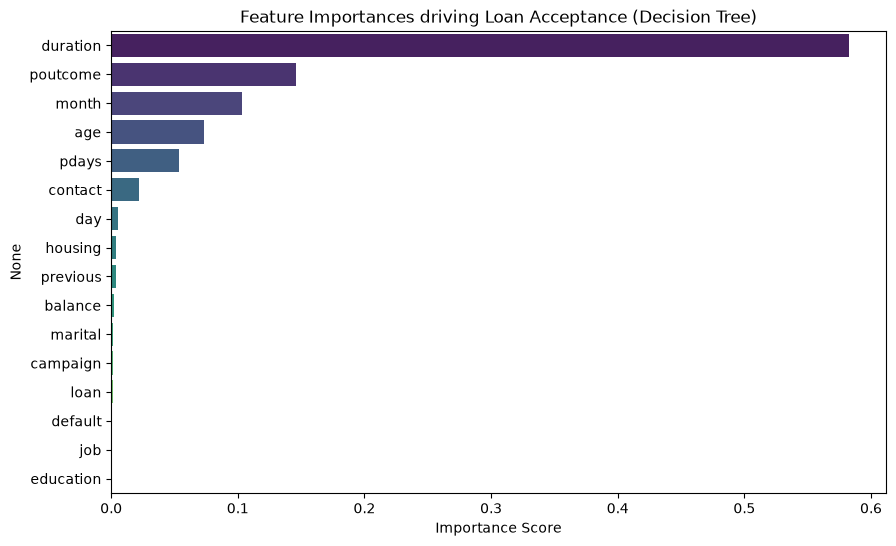

In [23]:
# Extract feature importances from the Decision Tree
importances = dt_model.feature_importances_
feature_names = X.columns

dt_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=dt_importances.values, y=dt_importances.index, hue=dt_importances.index, palette='viridis', legend=False)
plt.title('Feature Importances driving Loan Acceptance (Decision Tree)')
plt.xlabel('Importance Score')
plt.show()

### Evaluation Metrics & Model Comparison
While both models yield an overall accuracy of ~90%, the **Decision Tree Classifier** is significantly better suited for this business objective. 

* **The Problem with Accuracy:** Because only ~11.7% of the target audience accepts the offer, accuracy is inflated by how well the models predict the "no" class.
* **Why Decision Tree Wins:** It achieved a **Recall of 40%** for potential buyers, compared to the dismal **23% Recall** of Logistic Regression. This means using the Decision Tree allows the sales team to capture nearly twice as many actual conversions.

---
### Final Conclusion & Strategic Business Insights

#### Key Insights:
1. **The 'Golden' Minute:** `duration` is the single most dominant predictor. While duration is tracked *during* a call, agents should be trained with engaging hooks in the first 30 seconds to keep prospects on the line, as longer conversations strongly correlate with successful conversions.
2. **Leverage Historical Wins:** `poutcome` (previous campaign success) is highly influential. Customers who said yes in the past are prime targets; future campaigns should prioritize this segment first.
3. **Financial Freedom:** Features like `housing` play a pivotal role. Customers without current housing debts have higher disposable margins and show greater interest in taking on personal loans.

#### Strategic Recommendation:
The bank should deploy the **Decision Tree Classifier** to pre-filter and score contact lists before launching a campaign. Instead of blindly cold-calling the entire database, focusing marketing resources strictly on customers flagged as "high probability" by the model will drastically cut operational costs, maximize conversion rates, and prevent customer fatigue.